<a href="https://colab.research.google.com/github/raz0208/PedestrianDetection/blob/main/Model_Implementation%20/Pedestrian-Detection-(Object-Detection)-RK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Import Required Libraries

In [ ]:
import os
import numpy as np
import cv2
import json
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from PIL import Image
from collections import Counter
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.utils import Sequence
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# convert_and_copy_images

This function converts .tif images in a source directory to .jpg format and saves them in a specified destination directory while preserving folder structure.

In [ ]:
def convert_and_copy_images(src_dir, dest_dir):
    # Create the destination directory if it doesn't exist
    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)

    # Walk through all folders and subfolders in the source directory
    for root, dirs, files in os.walk(src_dir):
        for file in files:
            # Process only .tif files
            if file.lower().endswith('.tif'):
                # Full path to the .tif image
                file_path = os.path.join(root, file)

                # Open the .tif image and convert it to .jpg
                with Image.open(file_path) as img:
                    # Change the file extension to .jpg
                    new_file_name = os.path.splitext(file)[0] + '.jpg'
                    new_file_path = os.path.join(dest_dir, new_file_name)

                    # Convert and save as .jpg in the destination directory
                    img.convert("RGB").save(new_file_path, "JPEG")
# Example usage
source_folder = '/kaggle/input/city-persone/gtFinePanopticParts_trainval/gtFinePanopticParts/train'
destination_folder = '/kaggle/working/gtFinePanopticParts/train/images'
convert_and_copy_images(source_folder, destination_folder)

In [ ]:
def convert_and_copy_images(src_dir, dest_dir):
    # Create the destination directory if it doesn't exist
    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)

    # Walk through all folders and subfolders in the source directory
    for root, dirs, files in os.walk(src_dir):
        for file in files:
            # Process only .tif files
            if file.lower().endswith('.tif'):
                # Full path to the .tif image
                file_path = os.path.join(root, file)

                # Open the .tif image and convert it to .jpg
                with Image.open(file_path) as img:
                    # Change the file extension to .jpg
                    new_file_name = os.path.splitext(file)[0] + '.jpg'
                    new_file_path = os.path.join(dest_dir, new_file_name)

                    # Convert and save as .jpg in the destination directory
                    img.convert("RGB").save(new_file_path, "JPEG")
# Example usage
source_folder = '/kaggle/input/city-persone/gtFinePanopticParts_trainval/gtFinePanopticParts/val'
destination_folder = '/kaggle/working/gtFinePanopticParts/val/images'
convert_and_copy_images(source_folder, destination_folder)

# convert_json_to_yolo

This function converts JSON annotations containing bounding box coordinates into YOLO format text files. It normalizes the coordinates and assigns the appropriate class ID based on a predefined class mapping.

In [ ]:
# Mapping of class labels to YOLOv5 class IDs
class_mapping = {
    "pedestrian": 0,
    "rider": 1,
    "sitting person": 2,
    "person group": 3,
    "person (other)": 4
}

def convert_bbox_to_yolo(bbox, img_width, img_height):
    """
    Convert bounding box coordinates from [x_min, y_min, width, height]
    to YOLO format (x_center, y_center, width, height) normalized to image size.
    """
    x_min, y_min, width, height = bbox
    x_center = (x_min + width / 2) / img_width
    y_center = (y_min + height / 2) / img_height
    w = width / img_width
    h = height / img_height
    return x_center, y_center, w, h

def convert_json_to_yolo_txt(json_path, output_dir):
    """
    Convert the JSON annotation to YOLO text file format.
    """
    with open(json_path, 'r') as file:
        data = json.load(file)

    img_width = data["imgWidth"]
    img_height = data["imgHeight"]

    # Prepare the output filename based on the input JSON file
    txt_filename = os.path.splitext(os.path.basename(json_path))[0] + ".txt"
    txt_path = os.path.join(output_dir, txt_filename)

    with open(txt_path, 'w') as txt_file:
        for obj in data["objects"]:
            label = obj["label"]
            if label not in class_mapping:
                continue  # Skip labels that aren't in the class_mapping

            class_id = class_mapping[label]
            bbox = obj["bbox"]

            # Convert bounding box to YOLO format
            x_center, y_center, w, h = convert_bbox_to_yolo(bbox, img_width, img_height)

            # Write to the YOLO formatted .txt file
            txt_file.write(f"{class_id} {x_center} {y_center} {w} {h}\n")

def process_json_files_in_dir(src_dir, output_dir):
    """
    Walk through each folder and subfolder in src_dir, and process all JSON files.
    Convert them to YOLO text format.
    """
    for root, dirs, files in os.walk(src_dir):
        for file in files:
            if file.endswith('.json'):
                json_path = os.path.join(root, file)
                convert_json_to_yolo_txt(json_path, output_dir)

# Define input and output directories
src_dir = '/kaggle/input/city-persone/gtBbox_cityPersons_trainval/gtBboxCityPersons/val'
output_dir = '/kaggle/working/gtFinePanopticParts/val/labels'

# Make sure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Process all JSON files in the source directory and its subdirectories
process_json_files_in_dir(src_dir, output_dir)

# process_json_to_yolo

This script processes JSON annotation files containing bounding box data, converts them to the YOLO format, and saves them as .txt files. It ensures correct normalization and class mapping for training object detection models.

In [ ]:
# Mapping of class labels to YOLOv5 class IDs
class_mapping = {
    "pedestrian": 0,
    "rider": 1,
    "sitting person": 2,
    "person group": 3,
    "person (other)": 4
}

def convert_bbox_to_yolo(bbox, img_width, img_height):
    """
    Convert bounding box coordinates from [x_min, y_min, width, height]
    to YOLO format (x_center, y_center, width, height) normalized to image size.
    """
    x_min, y_min, width, height = bbox
    x_center = (x_min + width / 2) / img_width
    y_center = (y_min + height / 2) / img_height
    w = width / img_width
    h = height / img_height
    return x_center, y_center, w, h

def convert_json_to_yolo_txt(json_path, output_dir):
    """
    Convert the JSON annotation to YOLO text file format.
    """
    with open(json_path, 'r') as file:
        data = json.load(file)

    img_width = data["imgWidth"]
    img_height = data["imgHeight"]

    # Prepare the output filename based on the input JSON file
    txt_filename = os.path.splitext(os.path.basename(json_path))[0] + ".txt"
    txt_path = os.path.join(output_dir, txt_filename)

    with open(txt_path, 'w') as txt_file:
        for obj in data["objects"]:
            label = obj["label"]
            if label not in class_mapping:
                continue  # Skip labels that aren't in the class_mapping

            class_id = class_mapping[label]
            bbox = obj["bbox"]

            # Convert bounding box to YOLO format
            x_center, y_center, w, h = convert_bbox_to_yolo(bbox, img_width, img_height)

            # Write to the YOLO formatted .txt file
            txt_file.write(f"{class_id} {x_center} {y_center} {w} {h}\n")

def process_json_files_in_dir(src_dir, output_dir):
    """
    Walk through each folder and subfolder in src_dir, and process all JSON files.
    Convert them to YOLO text format.
    """
    for root, dirs, files in os.walk(src_dir):
        for file in files:
            if file.endswith('.json'):
                json_path = os.path.join(root, file)
                convert_json_to_yolo_txt(json_path, output_dir)

# Define input and output directories
src_dir = '/kaggle/input/city-persone/gtBbox_cityPersons_trainval/gtBboxCityPersons/train'
output_dir = '/kaggle/working/gtFinePanopticParts/train/labels'

# Make sure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Process all JSON files in the source directory and its subdirectories
process_json_files_in_dir(src_dir, output_dir)

# rename_annotation_files

This function renames all .txt annotation files in a given directory, replacing occurrences of "BboxCityPersons" with "FinePanopticParts" to ensure consistency in naming conventions.

In [ ]:
def rename_files_in_dir(output_dir):
    """
    Rename all .txt files in the output_dir by replacing 'BboxCityPersons' with 'FinePanopticParts'.
    """
    # Loop through all files in the directory
    for file_name in os.listdir(output_dir):
        # Check if the file is a .txt file
        if file_name.endswith('.txt'):
            # Replace 'BboxCityPersons' with 'FinePanopticParts' in the file name
            new_name = file_name.replace('BboxCityPersons', 'FinePanopticParts')

            # Get the full path of the old and new file names
            old_file_path = os.path.join(output_dir, file_name)
            new_file_path = os.path.join(output_dir, new_name)

            # Rename the file
            os.rename(old_file_path, new_file_path)

# Define the output directory where the text files are located
output_dir = '/kaggle/working/gtFinePanopticParts/val/labels'  # Replace with the actual path to your folder
output_dir1 = '/kaggle/working/gtFinePanopticParts/train/labels'  # Replace with the actual path to your folder

# Rename all .txt files in the directory
rename_files_in_dir(output_dir)
rename_files_in_dir(output_dir1)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


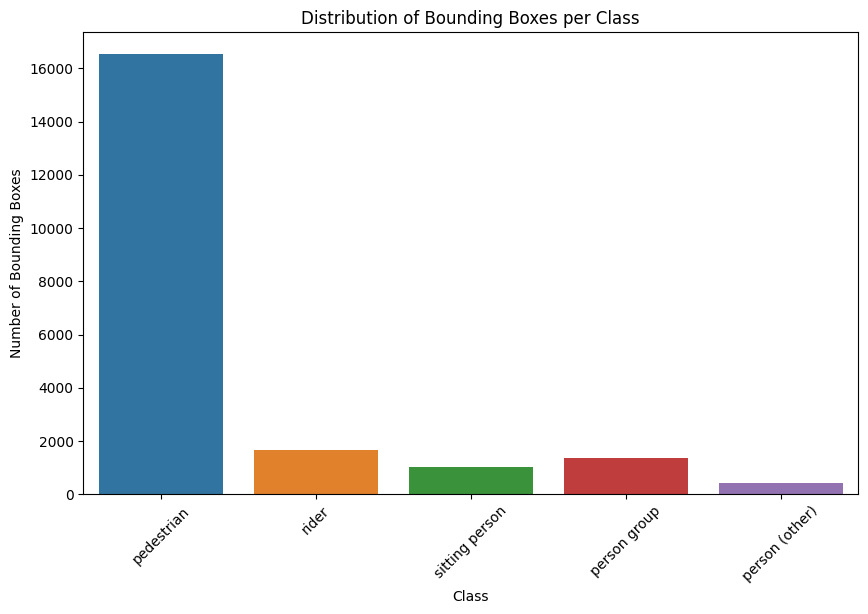

In [ ]:
# Define class mapping
class_mapping = {
    "pedestrian": 0,
    "rider": 1,
    "sitting person": 2,
    "person group": 3,
    "person (other)": 4
}

# Reverse mapping for better visualization
id_to_class = {v: k for k, v in class_mapping.items()}

# Function to count bounding boxes per class
def count_bboxes_in_dir(label_dir):
    bbox_counts = Counter()
    for file in os.listdir(label_dir):
        if file.endswith('.txt'):
            with open(os.path.join(label_dir, file), 'r') as f:
                for line in f:
                    class_id = int(line.split()[0])
                    bbox_counts[class_id] += 1
    return bbox_counts

# Specify the label directory (modify this path as needed)
label_dir = "/kaggle/working/gtFinePanopticParts/train/labels"

# Count bounding boxes per class
bbox_counts = count_bboxes_in_dir(label_dir)

# Convert counts to a sorted list
class_labels = [id_to_class[i] for i in sorted(bbox_counts.keys())]
counts = [bbox_counts[i] for i in sorted(bbox_counts.keys())]

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=class_labels, y=counts)
plt.xlabel("Class")
plt.ylabel("Number of Bounding Boxes")
plt.title("Distribution of Bounding Boxes per Class")
plt.xticks(rotation=45)
plt.show()


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


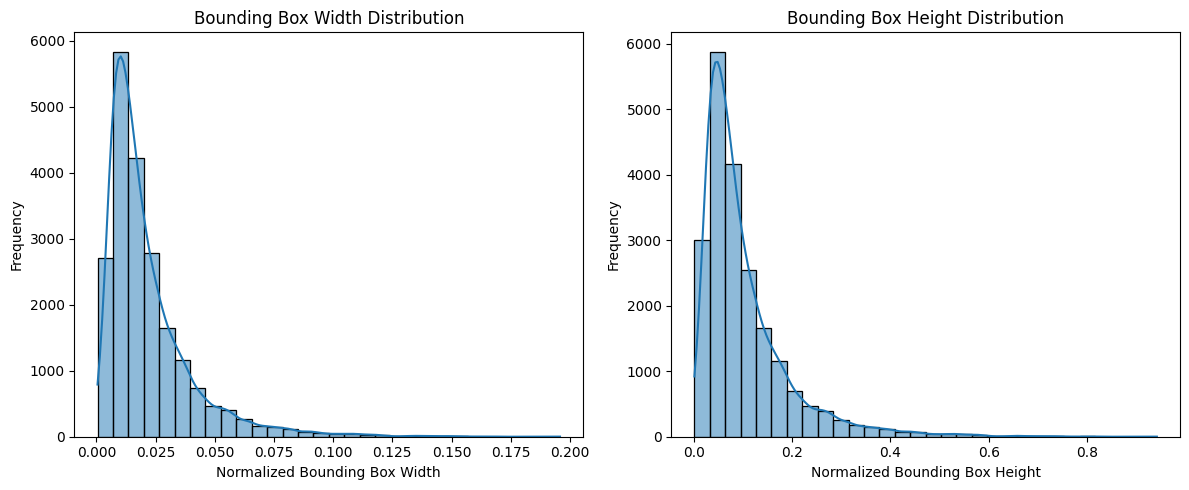

In [ ]:
# Function to extract bounding box sizes from YOLO annotation files
def get_bbox_sizes(label_dir):
    widths, heights = [], []

    for file in os.listdir(label_dir):
        if file.endswith('.txt'):
            with open(os.path.join(label_dir, file), 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        _, _, _, w, h = map(float, parts)  # Extract width and height
                        widths.append(w)
                        heights.append(h)

    return widths, heights

# Specify the label directory (modify as needed)
label_dir = "/kaggle/working/gtFinePanopticParts/train/labels"

# Get bounding box width and height distributions
widths, heights = get_bbox_sizes(label_dir)

# Plot distributions
plt.figure(figsize=(12, 5))

# Width distribution
plt.subplot(1, 2, 1)
sns.histplot(widths, bins=30, kde=True)
plt.xlabel("Normalized Bounding Box Width")
plt.ylabel("Frequency")
plt.title("Bounding Box Width Distribution")

# Height distribution
plt.subplot(1, 2, 2)
sns.histplot(heights, bins=30, kde=True)
plt.xlabel("Normalized Bounding Box Height")
plt.ylabel("Frequency")
plt.title("Bounding Box Height Distribution")

plt.tight_layout()
plt.show()


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


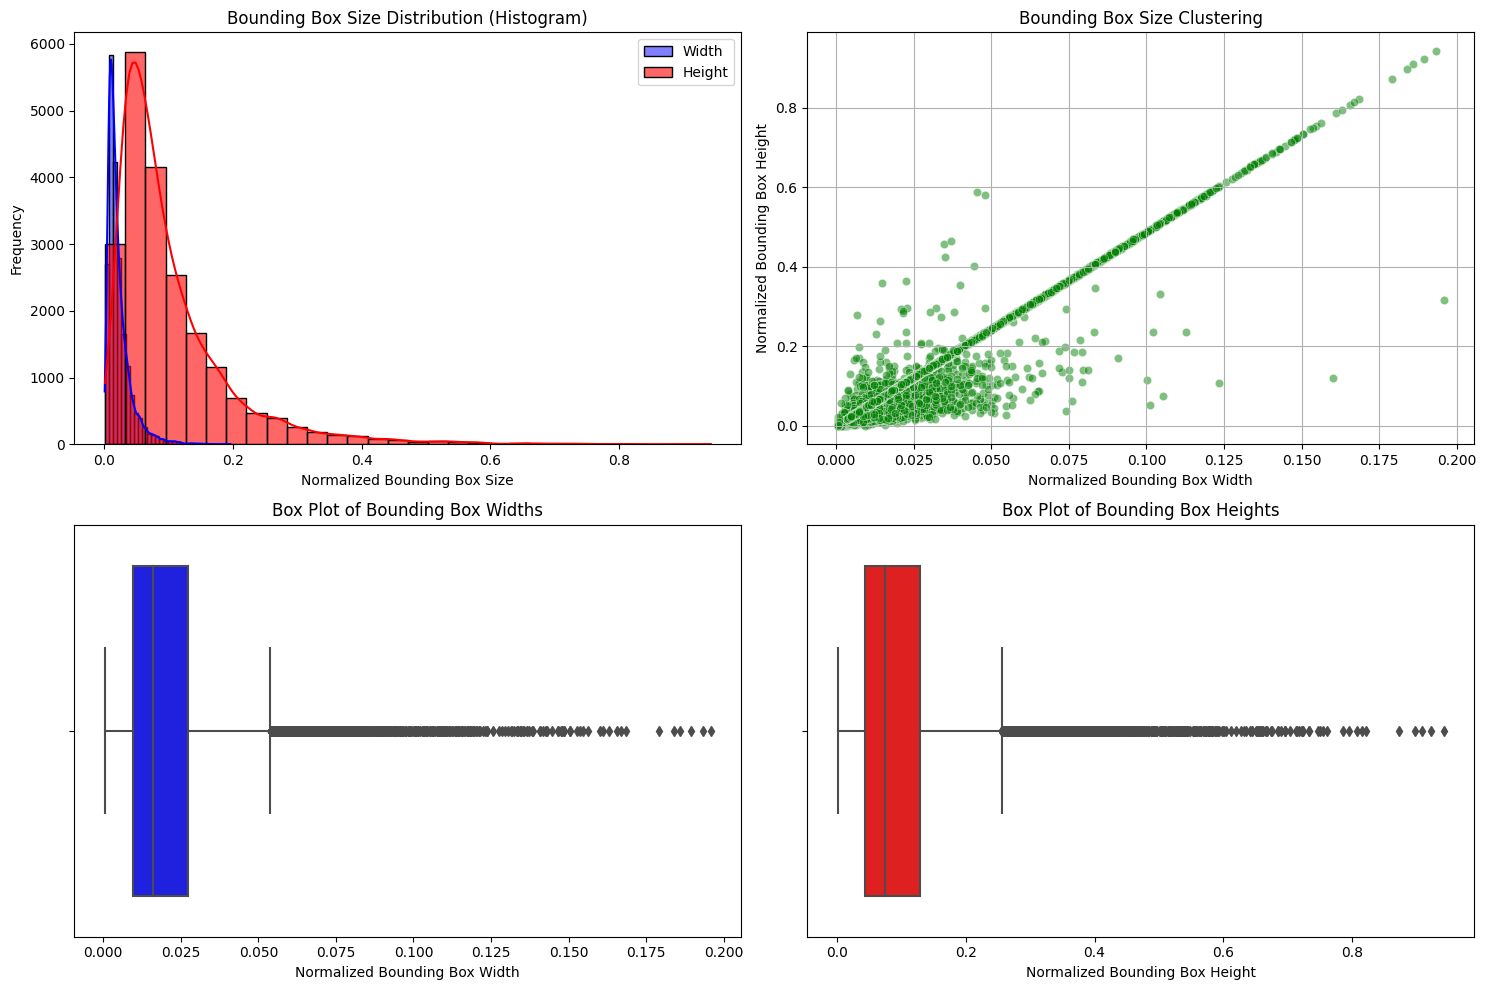

In [ ]:
# Function to extract bounding box sizes from YOLO annotation files
def get_bbox_sizes(label_dir):
    widths, heights = [], []

    for file in os.listdir(label_dir):
        if file.endswith('.txt'):
            with open(os.path.join(label_dir, file), 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        _, _, _, w, h = map(float, parts)  # Extract width and height
                        widths.append(w)
                        heights.append(h)

    return np.array(widths), np.array(heights)

# Specify the label directory (modify as needed)
label_dir = "/kaggle/working/gtFinePanopticParts/train/labels"

# Get bounding box width and height distributions
widths, heights = get_bbox_sizes(label_dir)

# Set up the figure
plt.figure(figsize=(15, 10))

# Histogram (Density Plot) for Widths and Heights
plt.subplot(2, 2, 1)
sns.histplot(widths, bins=30, kde=True, color="blue", label="Width")
sns.histplot(heights, bins=30, kde=True, color="red", label="Height", alpha=0.6)
plt.xlabel("Normalized Bounding Box Size")
plt.ylabel("Frequency")
plt.title("Bounding Box Size Distribution (Histogram)")
plt.legend()

# Scatter Plot for Bounding Box Clusters
plt.subplot(2, 2, 2)
sns.scatterplot(x=widths, y=heights, alpha=0.5, color="green")
plt.xlabel("Normalized Bounding Box Width")
plt.ylabel("Normalized Bounding Box Height")
plt.title("Bounding Box Size Clustering")
plt.grid(True)

# Box Plot for Bounding Box Widths
plt.subplot(2, 2, 3)
sns.boxplot(x=widths, color="blue")
plt.xlabel("Normalized Bounding Box Width")
plt.title("Box Plot of Bounding Box Widths")

# Box Plot for Bounding Box Heights
plt.subplot(2, 2, 4)
sns.boxplot(x=heights, color="red")
plt.xlabel("Normalized Bounding Box Height")
plt.title("Box Plot of Bounding Box Heights")

plt.tight_layout()
plt.show()


# load_and_split_dataset

This function loads images and their corresponding YOLO-format bounding box annotations, normalizes the coordinates, and splits the validation dataset into 90% validation and 10% test sets.

In [ ]:
from sklearn.model_selection import train_test_split


def load_images_and_annotations(image_folder, annotation_folder, file_extension='.jpg'):
    images = {}
    annotations = {}

    for filename in os.listdir(image_folder):
        if filename.endswith(file_extension):
            img_path = os.path.join(image_folder, filename)
            annotation_path = os.path.join(annotation_folder, filename.replace(file_extension, '.txt'))

            # Read image
            img = cv2.imread(img_path)
            if img is not None:
                images[filename] = img

                # Read bounding box annotations
                with open(annotation_path, 'r') as file:
                    bboxes = []
                    for line in file:
                        class_label, x_center, y_center, width, height = map(float, line.strip().split())

                        # Denormalize coordinates
                        x_center = int(x_center * img.shape[1])
                        y_center = int(y_center * img.shape[0])
                        width = int(width * img.shape[1])
                        height = int(height * img.shape[0])

                        # Convert to (x, y, width, height)
                        x = max(0, x_center - width // 2)
                        y = max(0, y_center - height // 2)
                        width = min(width, img.shape[1] - x)
                        height = min(height, img.shape[0] - y)

                        if width > 0 and height > 0:
                            bboxes.append((x, y, width, height, int(class_label)))

                    annotations[filename] = bboxes

    return images, annotations

# Define dataset paths
train_images, train_annotations = load_images_and_annotations('/kaggle/working/gtFinePanopticParts/train/images', '/kaggle/working/gtFinePanopticParts/train/labels')
val_images, val_annotations = load_images_and_annotations('/kaggle/working/gtFinePanopticParts/val/images', '/kaggle/working/gtFinePanopticParts/val/labels')

print(f"Loaded {len(train_images)} training images and {len(val_images)} validation images.")

# Splitting validation set into 90% validation and 10% test
val_images, test_images, val_annotations, test_annotations = train_test_split(
    list(val_images.items()), list(val_annotations.items()), test_size=0.1, random_state=42
)

# Convert back to dictionaries
val_images = dict(val_images)
test_images = dict(test_images)
val_annotations = dict(val_annotations)
test_annotations = dict(test_annotations)

print(f"Updated validation set: {len(val_images)} images")
print(f"Test set: {len(test_images)} images")

Loaded 2975 training images and 500 validation images.
Updated validation set: 450 images
Test set: 50 images


# crop the images

This function extracts and resizes image patches containing detected objects based on bounding box annotations, preparing the dataset for model training and evaluation.

In [ ]:
def crop_images(images, annotations, size=(96, 96)):
    cropped_images = []
    labels = []

    for image_id, bboxes in annotations.items():
        if image_id in images:
            img = images[image_id]
            for (x, y, width, height, class_label) in bboxes:
                cropped_img = img[y:y+height, x:x+width]
                if cropped_img.size > 0:
                    resized_img = cv2.resize(cropped_img, size)
                    cropped_images.append(resized_img)
                    labels.append(class_label)

    return np.array(cropped_images), np.array(labels)

# Crop and resize images
train_images_cropped, train_labels = crop_images(train_images, train_annotations)
val_images_cropped, val_labels = crop_images(val_images, val_annotations)

test_images_cropped, test_labels = crop_images(test_images, test_annotations)

print(f"Extracted {len(train_images_cropped)} cropped pedestrians for training.")
print(f"Extracted {len(val_images_cropped)} cropped pedestrians for validation.")
print(f"Extracted {len(test_images_cropped)} cropped pedestrians for testing.")

Extracted 21002 cropped pedestrians for training.
Extracted 3757 cropped pedestrians for validation.
Extracted 407 cropped pedestrians for testing.


# plot_class_distribution

This function visualizes the distribution of class labels across the training, validation, and test sets using a bar chart to ensure balanced dataset representation.

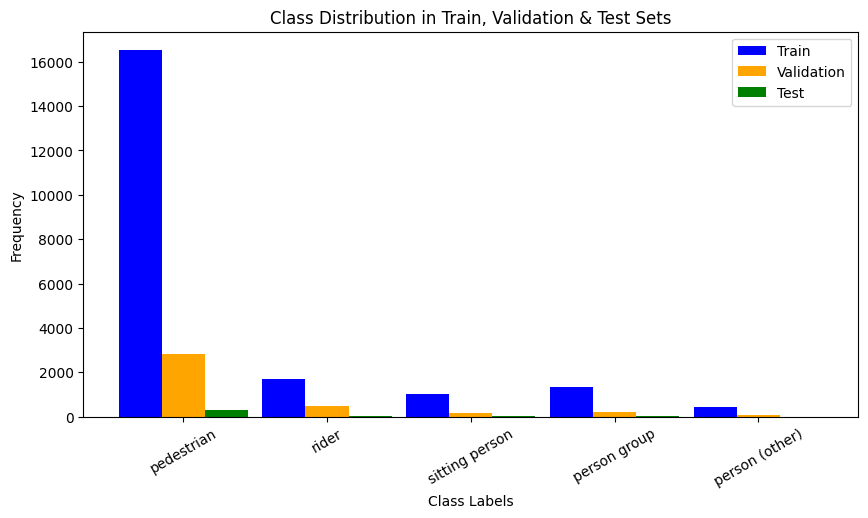

In [ ]:
# Count label occurrences
train_label_counts = Counter(train_labels)
val_label_counts = Counter(val_labels)
test_label_counts = Counter(test_labels)

# Get all unique labels
all_labels = sorted(set(train_label_counts.keys()).union(set(val_label_counts.keys())).union(set(test_label_counts.keys())))

# Prepare frequency data
train_frequencies = [train_label_counts[label] for label in all_labels]
val_frequencies = [val_label_counts[label] for label in all_labels]
test_frequencies = [test_label_counts[label] for label in all_labels]

# Define class names based on class_mapping
class_names = {0: "pedestrian", 1: "rider", 2: "sitting person", 3: "person group", 4: "person (other)"}
class_labels = [class_names[label] for label in all_labels]

# Plot the frequencies
fig, ax = plt.subplots(figsize=(10, 5))
bar_width = 0.3
x_indexes = np.arange(len(all_labels))

ax.bar(x_indexes - bar_width, train_frequencies, bar_width, label='Train', color='blue')
ax.bar(x_indexes, val_frequencies, bar_width, label='Validation', color='orange')
ax.bar(x_indexes + bar_width, test_frequencies, bar_width, label='Test', color='green')

ax.set_xlabel("Class Labels")
ax.set_ylabel("Frequency")
ax.set_title("Class Distribution in Train, Validation & Test Sets")
ax.set_xticks(x_indexes)
ax.set_xticklabels(class_labels, rotation=30)
ax.legend()

plt.show()


# print class distribution

This function counts and prints the occurrences of each class label in the training, validation, and test datasets to assess class balance.

In [ ]:
from collections import Counter
import numpy as np

# Count occurrences of each class label
train_label_counts = Counter(train_labels)
val_label_counts = Counter(val_labels)
test_label_counts = Counter(test_labels)

# Print class distribution
print("Class Distribution in Training Dataset:")
for class_id, count in sorted(train_label_counts.items()):
    print(f"Class {class_id}: {count} instances")

print('---------------------')
print("Class Distribution in Validation Dataset:")
for class_id, count in sorted(val_label_counts.items()):
    print(f"Class {class_id}: {count} instances")

print('---------------------')
print("Class Distribution in Test Dataset:")
for class_id, count in sorted(test_label_counts.items()):
    print(f"Class {class_id}: {count} instances")

Class Distribution in Training Dataset:
Class 0: 16526 instances
Class 1: 1680 instances
Class 2: 1032 instances
Class 3: 1347 instances
Class 4: 417 instances
---------------------
Class Distribution in Validation Dataset:
Class 0: 2837 instances
Class 1: 473 instances
Class 2: 171 instances
Class 3: 199 instances
Class 4: 77 instances
---------------------
Class Distribution in Test Dataset:
Class 0: 320 instances
Class 1: 36 instances
Class 2: 14 instances
Class 3: 27 instances
Class 4: 10 instances


# balance dataset

This function balances the dataset by downsampling the majority class and augmenting the minority classes to ensure a more uniform class distribution across training, validation, and test datasets.

In [ ]:
from collections import Counter
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def downsample_class(images, labels, target_size):
    indices = np.where(labels == labels[0])[0]
    if len(indices) > target_size:
        selected_indices = np.random.choice(indices, target_size, replace=False)
    else:
        selected_indices = indices
    return images[selected_indices], labels[selected_indices]

def augment_images(images, labels, target_size):
    datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    augmented_images = []
    augmented_labels = []

    for img, label in zip(images, labels):
        img = np.expand_dims(img, axis=0)
        count = 0
        for batch in datagen.flow(img, batch_size=1):
            augmented_images.append(batch[0].astype(np.uint8))
            augmented_labels.append(label)
            count += 1
            if count >= (target_size // len(images)):
                break

    return np.array(augmented_images), np.array(augmented_labels)

def balance_dataset(images, labels, target_size=5000):
    class_counts = Counter(labels)
    print("Original class distribution:", class_counts)

    balanced_images, balanced_labels = [], []

    for class_label in class_counts:
        class_images = images[labels == class_label]
        class_labels = labels[labels == class_label]

        if class_label == 0:
            imgs, lbls = downsample_class(class_images, class_labels, target_size)
        else:
            target_aug_size = min(target_size, len(class_images) * 3)
            imgs, lbls = augment_images(class_images, class_labels, target_aug_size)

        balanced_images.extend(imgs)
        balanced_labels.extend(lbls)

    balanced_images = np.array(balanced_images)
    balanced_labels = np.array(balanced_labels)

    print("New class distribution:", Counter(balanced_labels))
    return balanced_images, balanced_labels

train_images_balanced, train_labels_balanced = balance_dataset(train_images_cropped, train_labels)
val_images_balanced, val_labels_balanced = balance_dataset(val_images_cropped, val_labels)
test_images_balanced, test_labels_balanced = balance_dataset(test_images_cropped, test_labels)



Original class distribution: Counter({0: 16526, 1: 1680, 3: 1347, 2: 1032, 4: 417})
New class distribution: Counter({0: 5000, 3: 4041, 1: 3360, 2: 3096, 4: 1251})
Original class distribution: Counter({0: 2837, 1: 473, 3: 199, 2: 171, 4: 77})
New class distribution: Counter({0: 2837, 1: 1419, 3: 597, 2: 513, 4: 231})
Original class distribution: Counter({0: 320, 1: 36, 3: 27, 2: 14, 4: 10})
New class distribution: Counter({0: 320, 1: 108, 3: 81, 2: 42, 4: 30})


# compute class weights

This function calculates class weights based on the distribution of training labels to handle class imbalance during model training.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Define class labels
classes = np.array([0, 1, 2, 3, 4])

# Define the actual labels (repeated according to their counts)
y_train = np.concatenate([np.full(count, cls) for cls, count in Counter(train_labels).items()])

# Compute class weights correctly
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

# Convert to dictionary format
class_weights = dict(zip(classes, weights))

print("Class Weights:", class_weights)

Class Weights: {0: 0.2541691879462665, 1: 2.500238095238095, 2: 4.07015503875969, 3: 3.1183370452858203, 4: 10.072901678657074}


# extract features with mobilenet

This function extracts deep features from images using a pre-trained MobileNetV2 model, applying batch-wise feature extraction to optimize memory usage.

In [ ]:
import absl
# Suppress unnecessary TensorFlow warnings
absl.logging.set_verbosity(absl.logging.ERROR)
tf.get_logger().setLevel('ERROR')

# Load MobileNetV2 without the classification head
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
gap_layer = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=gap_layer)
feature_extractor.trainable = False  # Freeze pretrained weights

# Custom data generator for memory-efficient feature extraction
class FeatureExtractorGenerator(Sequence):
    def __init__(self, images, batch_size=32):
        self.images = np.array(images)  # Ensure it's a NumPy array
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.images))

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_images = self.images[batch_indexes]
        batch_images = preprocess_input(batch_images)  # Normalize images
        return batch_images

# Function to extract features in batches
def extract_features_in_batches(images, batch_size=32):
    generator = FeatureExtractorGenerator(images, batch_size)
    features = feature_extractor.predict(generator, verbose=1)
    return features

# Ensure train, val, and test images are NumPy arrays
train_images_cropped = np.array(train_images_cropped)
val_images_cropped = np.array(val_images_cropped)
test_images_cropped = np.array(test_images_cropped)

# Extract features in smaller batches to prevent memory overload
train_features = extract_features_in_batches(train_images_cropped, batch_size=32)
val_features = extract_features_in_batches(val_images_cropped, batch_size=32)
test_features = extract_features_in_batches(test_images_cropped, batch_size=32)

# Print final extracted feature shapes
print(f"Extracted train features shape: {train_features.shape}")
print(f"Extracted val features shape: {val_features.shape}")
print(f"Extracted test features shape: {test_features.shape}")





9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1741104646.781053     101 service.cc:145] XLA service 0x7df9a8038b90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1741104646.781124     101 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1741104646.781130     101 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


 30/657 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step

I0000 00:00:1741104650.511320     101 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


657/657 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step
Extracted train features shape: (21002, 1280)
Extracted val features shape: (3757, 1280)
Extracted test features shape: (407, 1280)


# train and evaluate classifiers

This function trains multiple classifiers (Logistic Regression, Random Forest, and SVM) on extracted features, evaluates them on validation and test sets, and visualizes performance using classification reports and confusion matrices.


Training Logistic Regression...


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression Validation Accuracy: 0.1331
Logistic Regression Test Accuracy: 0.1327

Classification Report (Validation):
              precision    recall  f1-score   support

           0       1.00      0.02      0.05      2837
           1       0.52      0.23      0.32       473
           2       0.05      0.99      0.10       171
           3       0.89      0.75      0.81       199
           4       0.56      0.06      0.12        77

    accuracy                           0.13      3757
   macro avg       0.60      0.41      0.28      3757
weighted avg       0.88      0.13      0.13      3757


Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      0.05      0.10       320
           1       0.31      0.14      0.19        36
           2       0.04      1.00      0.08        14
           3       0.86      0.67      0.75        27
           4       0.50      0.10      0.17        10

    accuracy               

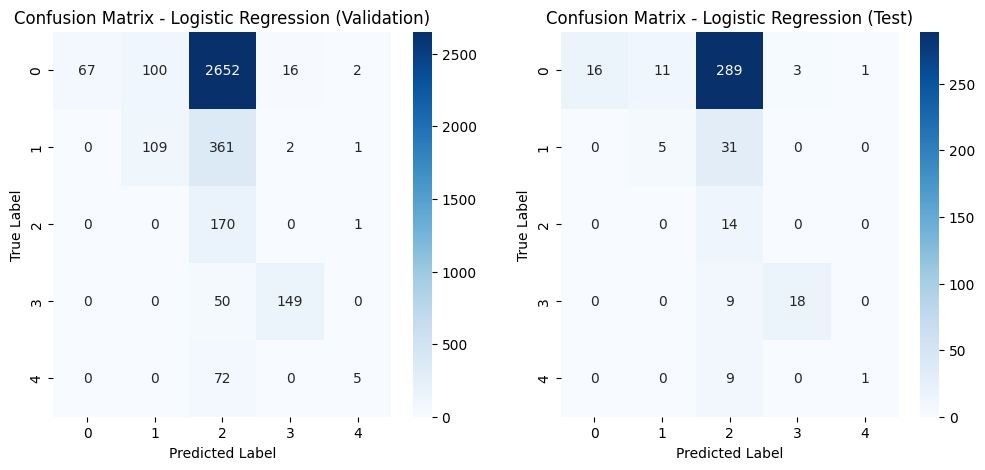


Training Random Forest...
Random Forest Validation Accuracy: 0.7993
Random Forest Test Accuracy: 0.8280

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.79      1.00      0.88      2837
           1       0.93      0.03      0.05       473
           2       0.83      0.14      0.24       171
           3       0.98      0.65      0.79       199
           4       0.00      0.00      0.00        77

    accuracy                           0.80      3757
   macro avg       0.71      0.36      0.39      3757
weighted avg       0.81      0.80      0.73      3757


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       320
           1       0.00      0.00      0.00        36
           2       1.00      0.14      0.25        14
           3       1.00      0.56      0.71        27
           4       0.00      0.00      0.00        10

    accuracy

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


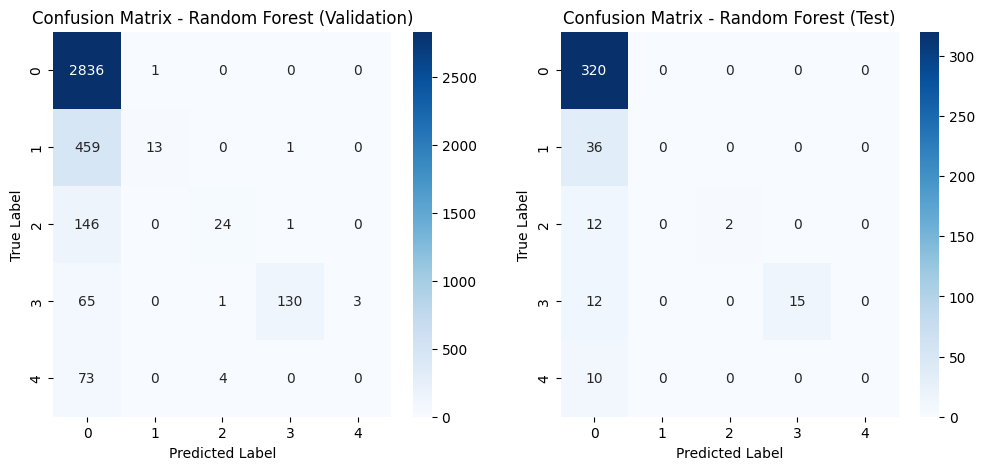


Training SVM...
SVM Validation Accuracy: 0.8076
SVM Test Accuracy: 0.8133

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.95      0.83      0.88      2837
           1       0.48      0.75      0.59       473
           2       0.49      0.70      0.57       171
           3       0.91      0.91      0.91       199
           4       0.31      0.36      0.34        77

    accuracy                           0.81      3757
   macro avg       0.63      0.71      0.66      3757
weighted avg       0.85      0.81      0.82      3757


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       320
           1       0.43      0.81      0.56        36
           2       0.30      0.64      0.41        14
           3       0.95      0.78      0.86        27
           4       0.50      0.20      0.29        10

    accuracy                           0.8

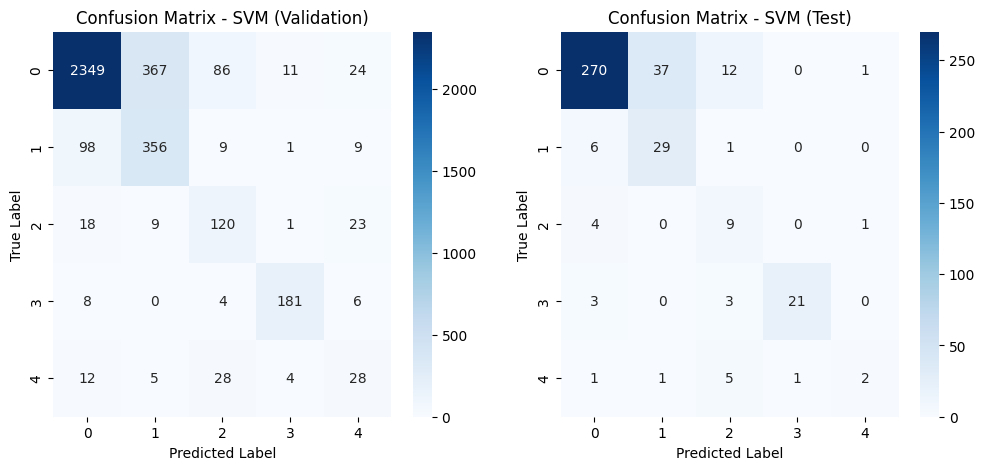


Final Model Performance Comparison:
Logistic Regression: Validation Accuracy = 0.1331, Test Accuracy = 0.1327
Random Forest: Validation Accuracy = 0.7993, Test Accuracy = 0.8280
SVM: Validation Accuracy = 0.8076, Test Accuracy = 0.8133


In [ ]:
# Normalize the extracted features
train_features_norm = train_features / np.linalg.norm(train_features, axis=1, keepdims=True)
val_features_norm = val_features / np.linalg.norm(val_features, axis=1, keepdims=True)
test_features_norm = test_features / np.linalg.norm(test_features, axis=1, keepdims=True)

# Define classifiers with class weights
classifiers = {
    "Logistic Regression": LogisticRegression(class_weight=class_weights, max_iter=500, solver='saga', n_jobs=-1),
    "Random Forest": RandomForestClassifier(class_weight=class_weights, n_estimators=100, random_state=42, n_jobs=-1),
    "SVM": SVC(class_weight=class_weights, kernel='rbf', probability=True)
}

# Train and evaluate each model
results = {}

for name, clf in classifiers.items():
    print(f"\nTraining {name}...")
    clf.fit(train_features_norm, train_labels)  # Train the model

    # Predict on validation and test set
    val_preds = clf.predict(val_features_norm)
    test_preds = clf.predict(test_features_norm)

    # Evaluate performance
    val_accuracy = accuracy_score(val_labels, val_preds)
    test_accuracy = accuracy_score(test_labels, test_preds)
    print(f"{name} Validation Accuracy: {val_accuracy:.4f}")
    print(f"{name} Test Accuracy: {test_accuracy:.4f}")
    print("\nClassification Report (Validation):")
    print(classification_report(val_labels, val_preds))
    print("\nClassification Report (Test):")
    print(classification_report(test_labels, test_preds))

    # Store results
    results[name] = (val_accuracy, test_accuracy, val_preds, test_preds)

    # Confusion Matrices
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.heatmap(confusion_matrix(val_labels, val_preds), annot=True, cmap="Blues", fmt="d")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {name} (Validation)")

    plt.subplot(1, 2, 2)
    sns.heatmap(confusion_matrix(test_labels, test_preds), annot=True, cmap="Blues", fmt="d")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {name} (Test)")
    plt.show()

# Compare results
print("\nFinal Model Performance Comparison:")
for name, (val_accuracy, test_accuracy, _, _) in results.items():
    print(f"{name}: Validation Accuracy = {val_accuracy:.4f}, Test Accuracy = {test_accuracy:.4f}")


In [ ]:
num_classes = len(np.unique(train_labels))
print("Number of classes:", num_classes)

Number of classes: 5


# train neural network classifier

This function defines, compiles, and trains a deep neural network classifier on extracted features using class weights and early stopping, then evaluates the model on validation and test sets.

In [ ]:
# Define a deeper neural network classifier
classifier = Sequential([
    Dense(1024, activation='relu', input_shape=(train_features.shape[1],)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])

# Compile the model
classifier.compile(optimizer=Adam(learning_rate=0.0001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Early stopping to avoid overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# Train the deeper classifier
history = classifier.fit(train_features_norm, train_labels,
                         validation_data=(val_features_norm, val_labels),
                         epochs=50, batch_size=64, verbose=1,
                         class_weight=class_weights,
                         callbacks=[early_stopping])

# Evaluate on validation and test set
val_loss, val_acc = classifier.evaluate(val_features_norm, val_labels)
test_loss, test_acc = classifier.evaluate(test_features_norm, test_labels)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# Model summary
classifier.summary()



/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.2495 - loss: 1.8907 - val_accuracy: 0.1334 - val_loss: 1.6007
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3271 - loss: 1.3512 - val_accuracy: 0.5105 - val_loss: 1.1665
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3800 - loss: 1.1397 - val_accuracy: 0.5627 - val_loss: 1.0451
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4406 - loss: 1.0498 - val_accuracy: 0.6082 - val_loss: 0.9642
Epoch 5/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4624 - loss: 0.9713 - val_accuracy: 0.6401 - val_loss: 0.8910
Epoch 6/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5099 - loss: 0.9090 - val_accuracy: 0.6707 - val_loss: 0.8309
Epoch 7/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5469 - loss: 0.8393 - val_accuracy: 0.7016 - val_loss: 0.7717
Epoch 8/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5645 - loss: 0.8556 - val_accuracy: 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,019,601 (22.96 MB)

 Trainable params: 2,005,253 (7.65 MB)

 Non-trainable params: 3,840 (15.00 KB)

 Optimizer params: 4,010,508 (15.30 MB)

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


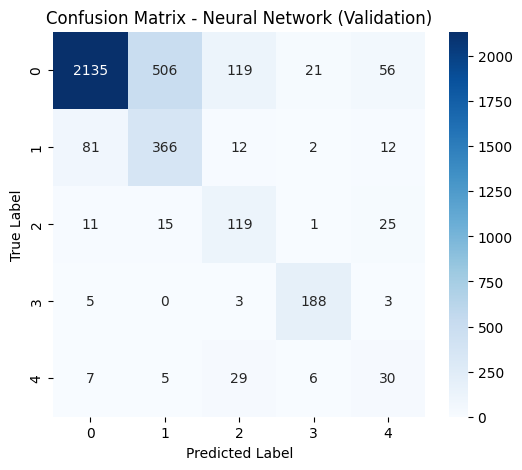


Classification Report - Neural Network (Validation):
              precision    recall  f1-score   support

           0       0.95      0.75      0.84      2837
           1       0.41      0.77      0.54       473
           2       0.42      0.70      0.53       171
           3       0.86      0.94      0.90       199
           4       0.24      0.39      0.30        77

    accuracy                           0.76      3757
   macro avg       0.58      0.71      0.62      3757
weighted avg       0.84      0.76      0.78      3757



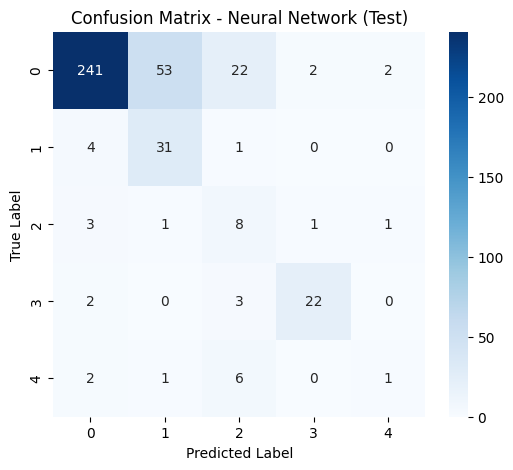


Classification Report - Neural Network (Test):
              precision    recall  f1-score   support

           0       0.96      0.75      0.84       320
           1       0.36      0.86      0.51        36
           2       0.20      0.57      0.30        14
           3       0.88      0.81      0.85        27
           4       0.25      0.10      0.14        10

    accuracy                           0.74       407
   macro avg       0.53      0.62      0.53       407
weighted avg       0.86      0.74      0.78       407



In [ ]:


# Function to plot confusion matrix
def plot_confusion_matrix(true_labels, predicted_labels, model_name="Model"):
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(true_labels), yticklabels=np.unique(true_labels))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    # Print classification report
    print(f"\nClassification Report - {model_name}:")
    print(classification_report(true_labels, predicted_labels))

# Predict class labels on validation and test set
nn_val_preds = np.argmax(classifier.predict(val_features_norm), axis=1)
nn_test_preds = np.argmax(classifier.predict(test_features_norm), axis=1)

# Plot confusion matrix for the neural network classifier
plot_confusion_matrix(val_labels, nn_val_preds, "Neural Network (Validation)")
plot_confusion_matrix(test_labels, nn_test_preds, "Neural Network (Test)")


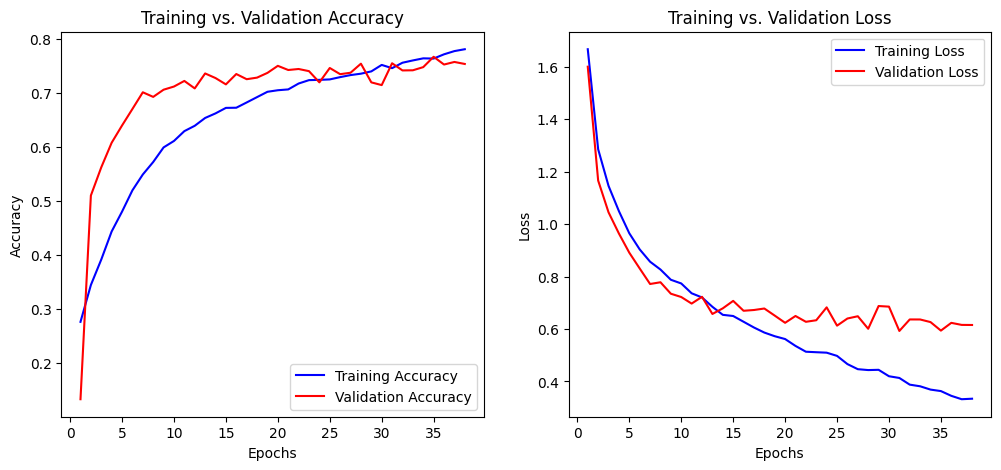

In [ ]:
# Plot training & validation accuracy and loss
def plot_training_history(history):
    epochs = range(1, len(history.history['accuracy']) + 1)

    # Accuracy Plot
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['accuracy'], 'b', label='Training Accuracy')
    plt.plot(epochs, history.history['val_accuracy'], 'r', label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training vs. Validation Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['loss'], 'b', label='Training Loss')
    plt.plot(epochs, history.history['val_loss'], 'r', label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training vs. Validation Loss')
    plt.legend()

    plt.show()

# Call the function to visualize
plot_training_history(history)


# Mobilenetv2

This function fine-tunes a pre-trained MobileNetV2 model by unfreezing the last 30 layers, adding a custom classification head, and training with data augmentation, early stopping, and learning rate reduction.

In [ ]:
# Load MobileNetV2 with pretrained weights but do not include the top layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3))

# Unfreeze the last few layers for fine-tuning
for layer in base_model.layers[-30:]:  # Unfreeze last 30 layers
    layer.trainable = True

# Add a Global Average Pooling layer
gap_layer = GlobalAveragePooling2D()(base_model.output)

# Add classification head
x = Dense(1024, activation='relu')(gap_layer)  # Increased neurons
x = BatchNormalization()(x)
x = Dropout(0.6)(x)  # Increased dropout

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)  # Increased dropout

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

output_layer = Dense(num_classes, activation='softmax')(x)  # Use correct num_classes

# Create the fine-tuned model
fine_tune_model = Model(inputs=base_model.input, outputs=output_layer)

# Compile the model with a lower learning rate for fine-tuning
fine_tune_model.compile(optimizer=Adam(learning_rate=0.00001),  # Reduced learning rate
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

# Print model summary
fine_tune_model.summary()

# Data augmentation to help generalization
datagen = ImageDataGenerator(
    rotation_range=30,  # Increased rotation range
    width_shift_range=0.3,  # Increased shift range
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = datagen.flow(train_images_cropped, train_labels, batch_size=32)

# Early stopping and learning rate reduction callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)

# Train the fine-tuned model with data augmentation
history_fine_tune = fine_tune_model.fit(train_generator,
                                        validation_data=(val_images_cropped, val_labels),
                                        epochs=30, batch_size=32, verbose=1,
                                        callbacks=[early_stop, lr_reduce])

# Evaluate fine-tuned model
val_loss, val_acc = fine_tune_model.evaluate(val_images_cropped, val_labels)
test_loss, test_acc = fine_tune_model.evaluate(test_images_cropped, test_labels)
print(f"Fine-Tuned Model Validation Accuracy: {val_acc * 100:.2f}%")
print(f"Fine-Tuned Model Test Accuracy: {test_acc * 100:.2f}%")


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 4,234,309 (16.15 MB)

 Trainable params: 4,196,613 (16.01 MB)

 Non-trainable params: 37,696 (147.25 KB)

Epoch 1/30


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


657/657 ━━━━━━━━━━━━━━━━━━━━ 118s 114ms/step - accuracy: 0.2252 - loss: 2.5129 - val_accuracy: 0.0990 - val_loss: 2.1388 - learning_rate: 1.0000e-05
Epoch 2/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 50s 76ms/step - accuracy: 0.2802 - loss: 2.2394 - val_accuracy: 0.3492 - val_loss: 1.4937 - learning_rate: 1.0000e-05
Epoch 3/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 50s 75ms/step - accuracy: 0.3467 - loss: 1.9820 - val_accuracy: 0.4421 - val_loss: 1.3215 - learning_rate: 1.0000e-05
Epoch 4/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 49s 74ms/step - accuracy: 0.4062 - loss: 1.7657 - val_accuracy: 0.5856 - val_loss: 1.1537 - learning_rate: 1.0000e-05
Epoch 5/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 49s 74ms/step - accuracy: 0.4761 - loss: 1.5802 - val_accuracy: 0.6942 - val_loss: 1.0051 - learning_rate: 1.0000e-05
Epoch 6/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 50s 75ms/step - accuracy: 0.5251 - loss: 1.4676 - val_accuracy: 0.7554 - val_loss: 0.9120 - learning_rate: 1.0000e-05
Epoch 7/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 49s 75ms/step - accur

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step


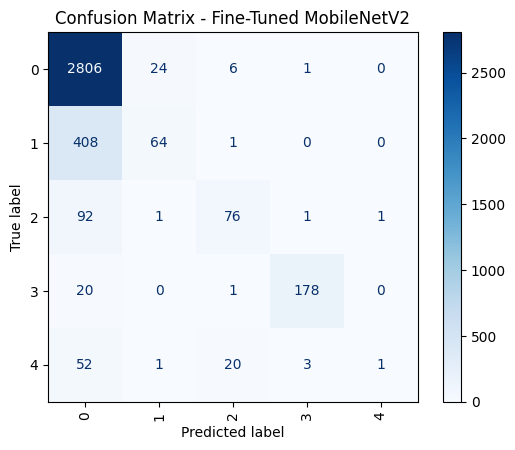

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Predict class labels on validation set
fine_tune_preds = np.argmax(fine_tune_model.predict(val_images_cropped), axis=1)  # Get predicted class indices

# Generate confusion matrix
cm = confusion_matrix(val_labels, fine_tune_preds)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(val_labels))
disp.plot(cmap=plt.cm.Blues, xticks_rotation="vertical")
plt.title("Confusion Matrix - Fine-Tuned MobileNetV2")
plt.show()


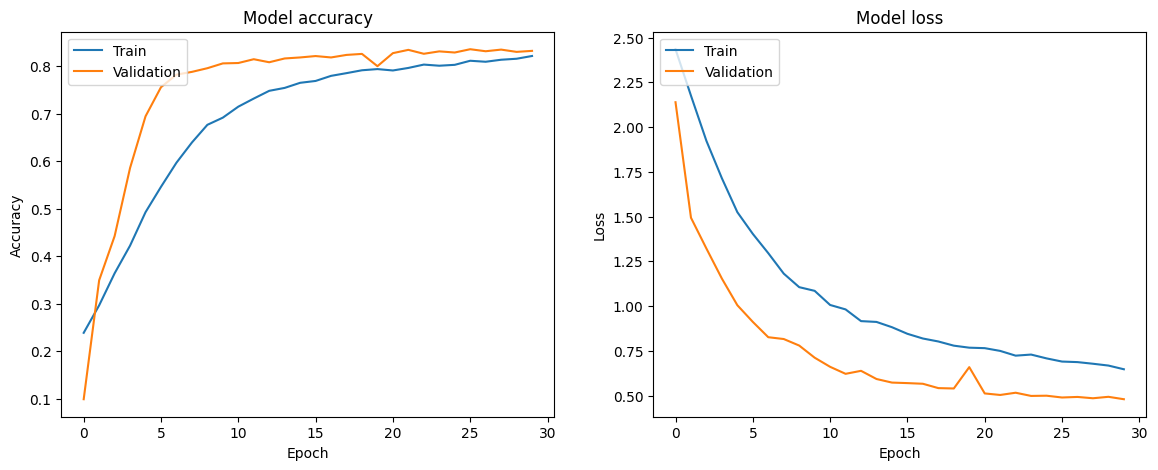

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_fine_tune.history['accuracy'])
plt.plot(history_fine_tune.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_fine_tune.history['loss'])
plt.plot(history_fine_tune.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


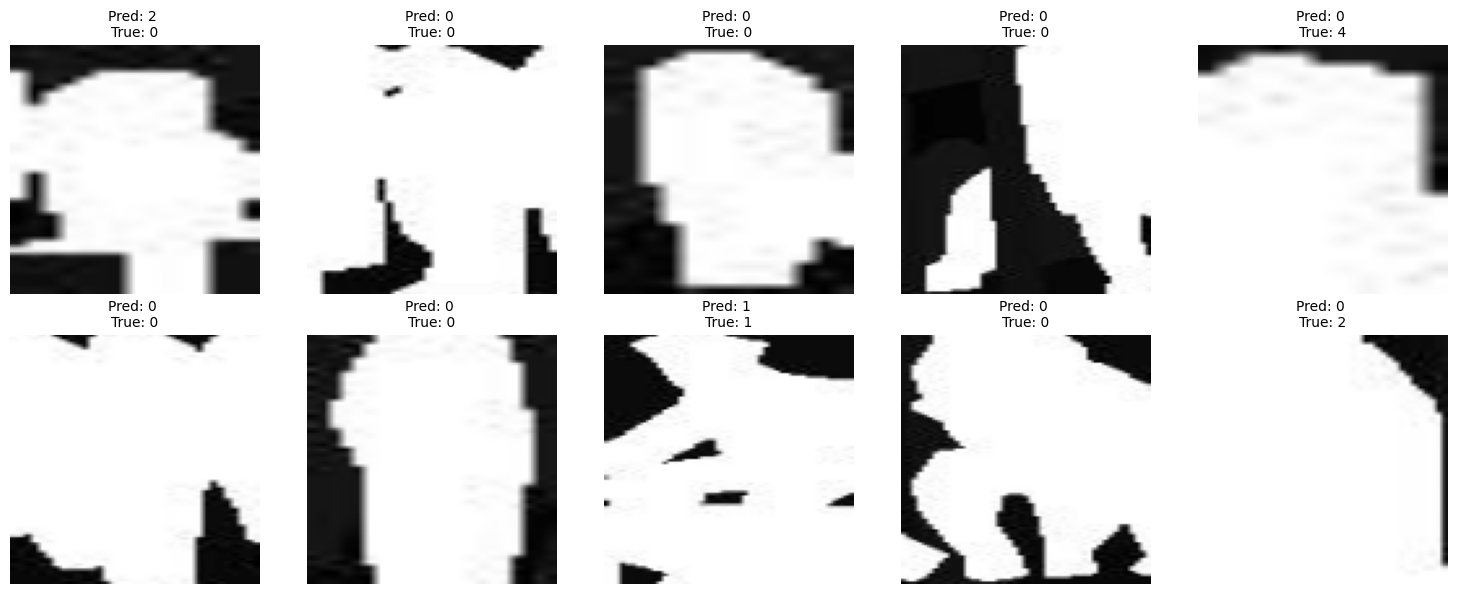

In [ ]:
import matplotlib.pyplot as plt
import random

# Select 10 random indices from validation set
random_indices = random.sample(range(len(val_images_cropped)), 10)

# Get the corresponding images and labels
sample_images = val_images_cropped[random_indices]
sample_labels = val_labels[random_indices]

# Predict the class probabilities
predictions = fine_tune_model.predict(sample_images)
predicted_classes = np.argmax(predictions, axis=1)  # Get class with highest probability

# Plot the images with predictions
plt.figure(figsize=(15, 6))

for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)  # Create a 2-row, 5-column grid
    plt.imshow(sample_images[i].astype("uint8"))  # Show image
    plt.axis("off")  # Hide axes
    plt.title(f"Pred: {predicted_classes[i]} \nTrue: {sample_labels[i]}", fontsize=10)

plt.tight_layout()
plt.show()
